# Moondream

In [1]:
GROUP_NAME = "moondream"
RESULT_PATH = "../output/result_1766691418_20250506_20250506T_20251123_20251124.csv"

## Setup

In [64]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.1

Matrix products: default


locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.1            performance_0.14.0     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_3.5.1          marginaleffects_0.25.1
[10] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE)
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [4]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

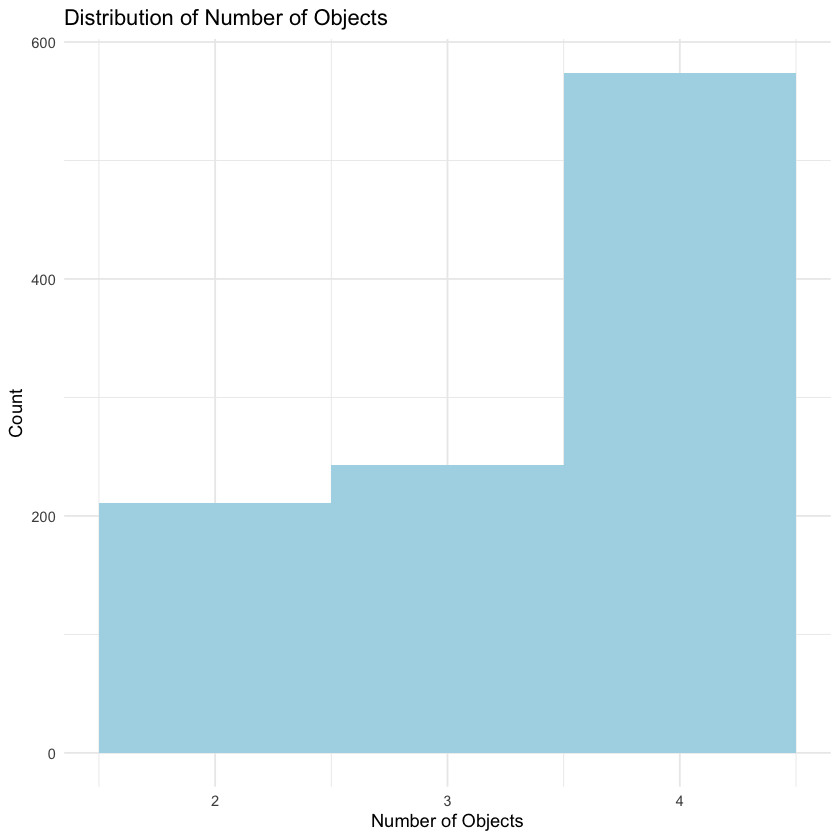

In [5]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [6]:
#m_effects1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
#m_effects2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
#m_effects3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
#m_effects4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
#isSingular(m_effects1)
#isSingular(m_effects2)
#isSingular(m_effects3)
#isSingular(m_effects4)
#compare_performance(m_effects1, m_effects2, m_effects3, m_effects4, rank = TRUE)

In [7]:
#anova(m_effects2, m_effects3)
m_effects_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)

In [8]:
m_effects <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_wrongness) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,7,989.1447,1020.590,-487.5723,975.1447,NA,NA,NA
m_effects_c,25,1005.0084,1117.314,-477.5042,955.0084,20.13627,18,0.3252003


In [9]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.08007103,0.01574824,5.084444,3.687055e-07,21.37103,0.04920505,0.110937,0.3798494,0.3798627,0.379856


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.02891913,0.01641908,1.761312,0.07818554,3.676954,-0.003261677,0.06109994,0.3798512,0.3798608,0.379856


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.11200513,0.03217967,3.480618,0.0005002582,10.965040,0.04893414,0.1750761
Angle,right - front,0.04241321,0.03028369,1.400530,0.1613547420,2.631692,-0.01694173,0.1017681


In [10]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Candidates)
   Data: df_replicate
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
   989.1   1020.6   -487.6    975.1      653 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4525 -0.6893 -0.4484  0.6733  2.8141 

Random effects:
 Groups     Name        Variance Std.Dev.
 Candidates (Intercept) 0.004326 0.06577 
Number of obs: 660, groups:  Candidates, 13

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -1.48078    0.14865  -9.961  < 2e-16 ***
scale(Proximity, scale = FALSE)     0.33086    0.08359   3.958 7.56e-05 ***
Angleleft                           0.64934  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),99.2258592,1,2.252861e-23
"scale(Proximity, scale = FALSE)",15.6653552,1,7.559629e-05
Angle,14.8843195,2,5.860182e-04
"scale(n_candidates, scale = FALSE)",2.4935243,1,1.143155e-01
Condition,0.6581014,1,4.172310e-01


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.4807779,0.14865431,-9.9612178,0.00000000000000000000002252861,-1.77214039,-1.1894155,1.814992,-0.81585942
"scale(Proximity, scale = FALSE)",0.3308552,0.08359259,3.9579484,0.00007559629448462390054891413,0.16701368,0.4946966,1.814992,0.18229020
Angleleft,0.6493437,0.16831051,3.8580103,0.00011431384376539013240231535,0.31945508,0.9792323,1.814992,0.35776678
Angleright,0.3750281,0.17250647,2.1739944,0.02970555832801578810542508791,0.03691541,0.7131408,1.814992,0.20662801
"scale(n_candidates, scale = FALSE)",0.1468714,0.09301014,1.5790897,0.11431548022055879054725835431,-0.03542852,0.3291712,1.814992,0.08092124
Conditioncongruent,-0.1094577,0.13492730,-0.8112345,0.41723101801854245440637214415,-0.37391518,0.1549998,1.814992,-0.06030754


NA
NA
NA
1.8149915
-1.4807779
0.1486543
0.6493437
0.1683105
0.0001143
0.3577668
0.3750281
0.1725065
0.0297056
0.2066280
0.3308552
0.0835926
0.0000756
0.1822902
0.1468714
0.0930101
0.1143155
0.0809212


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [11]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
m_head_bias <- glmer(
  IsHeadTarget ~ 1 + (1 | Candidates),
#  IsHeadTarget ~ 1 + (1 | Candidates) + (1 | Stimulus_ID) + (1 | Prompt_ID),
  data = df_test21, 
  family = binomial
)
summary(m_head_bias)

[1] 0.6683544

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: IsHeadTarget ~ 1 + (1 | Candidates)
   Data: df_test21

     AIC      BIC   logLik deviance df.resid 
   505.4    513.4   -250.7    501.4      393 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.5231 -1.3213  0.6651  0.7030  0.7617 

Random effects:
 Groups     Name        Variance Std.Dev.
 Candidates (Intercept) 0.03652  0.1911  
Number of obs: 395, groups:  Candidates, 7

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.6992     0.1303   5.368 7.94e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [12]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    # Formula: (1 / n_candidates) ^ (steps - 1)
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
t.test(df_test22$is_stable, mu = mean(df_test22$chance_baseline), alternative = "greater")

Actual Stability Rate:  0.7447447 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  df_test22$is_stable
t = 22.609, df = 332, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0.203735
95 percent confidence interval:
 0.7052751       Inf
sample estimates:
mean of x 
0.7447447 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [13]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.597561

[1] 0.2342857

In [14]:
model_cond <- glm(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) * Condition + offset(offset_accuracy), data = df_unnatural, family = binomial)
#model_cond <- glmer(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) * Condition + offset(offset_accuracy) + (1|Candidates) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
#isSingular(model_cond)

In [15]:
avg_predictions(model_cond, variables = "Condition")

Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.5583014,0.02718910,20.53401,1.069620e-93,308.8422,0.5050118,0.6115911
incongruent,0.2402180,0.01621557,14.81403,1.188886e-49,162.5249,0.2084360,0.2719999


In [16]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.3180835,0.03165741,-10.04768,9.405663e-24,76.49274,-0.3801308,-0.2560361


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [17]:
#m_dist1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
#m_dist2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
#m_dist3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
#m_dist4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_unnatural, family = binomial, control = strict_control)
    
#isSingular(m_dist1)
#isSingular(m_dist2)
#isSingular(m_dist3)
#isSingular(m_dist4)
#compare_performance(m_dist1, m_dist2, m_dist3, m_dist4, rank = TRUE)

In [18]:
m_dist_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_dist_c, m_dist)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist,7,1824.419,1858.967,-905.2095,1810.419,NA,NA,NA
m_dist_c,25,1807.842,1931.226,-878.9208,1757.842,52.57739,18,3.049202e-05


In [19]:
avg_slopes(m_dist_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.2047168,0.01203777,17.00621,7.386714e-65,213.0404,0.1811232,0.2283104,0.3736502,0.3736772,0.3736637


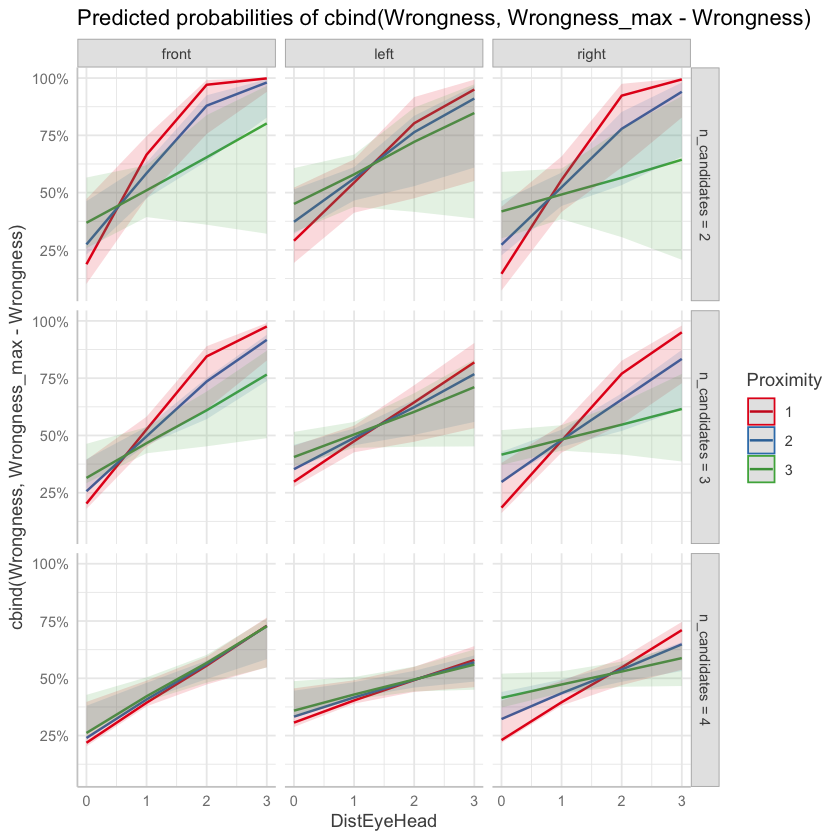

In [20]:
plot(ggpredict(
  m_dist_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

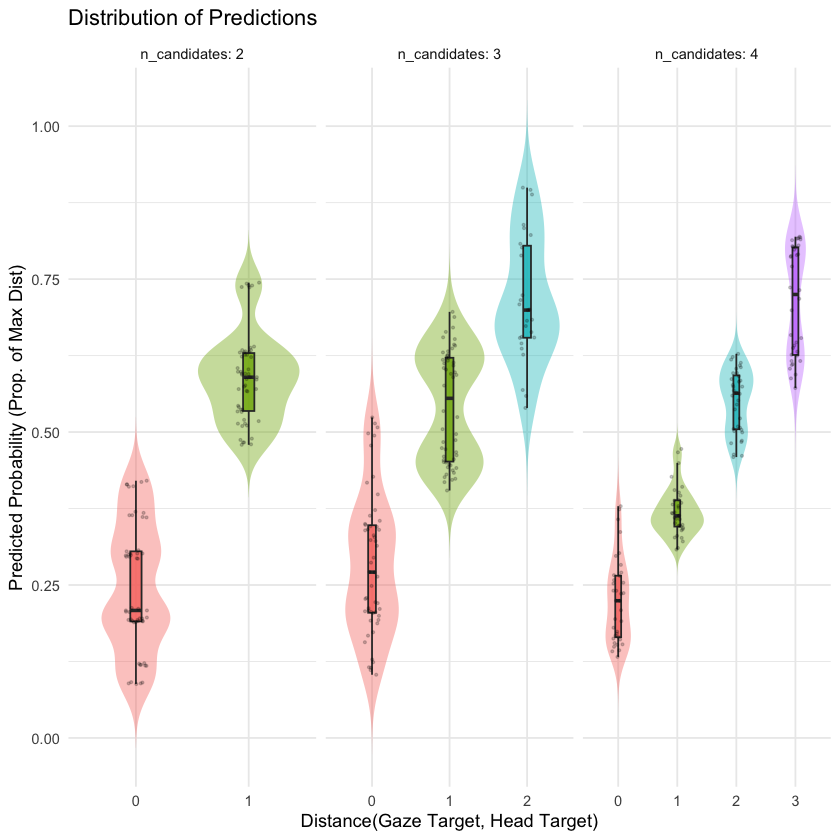

In [21]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Candidates)
preds <- predictions(m_dist_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

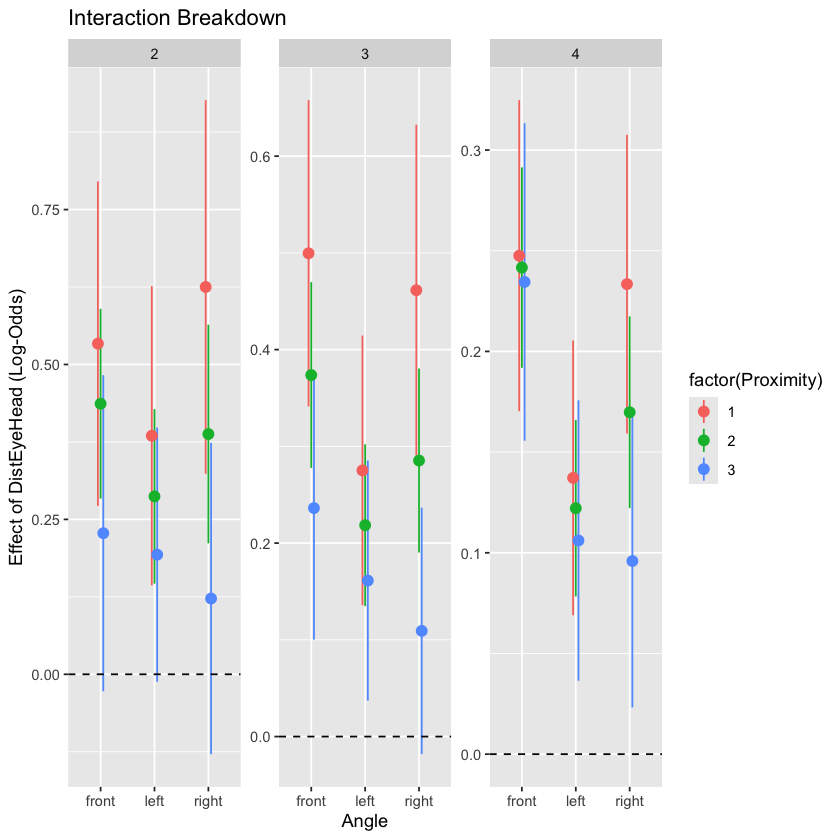

In [22]:
plot_slopes(
  m_dist_c,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [23]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Proximity")

term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.2551030,0.01422226,17.936882,6.077062e-72,236.57545,0.2272278,0.2829781
DistEyeHead,dY/dX,2,0.2136356,0.01198200,17.829709,4.155755e-71,233.80178,0.1901513,0.2371199
DistEyeHead,dY/dX,3,0.1464342,0.02314586,6.326581,2.506525e-10,31.89359,0.1010691,0.1917993


In [24]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.0864425,0.02843522,-3.0399795,0.002365943,8.723369,-0.14217451,-0.030710481
(right) - (front),-0.0560431,0.02730858,-2.0522153,0.040148742,4.638501,-0.10956694,-0.002519253
(right) - (left),0.0303994,0.03093450,0.9827021,0.325754057,1.618145,-0.03023111,0.091029908


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [25]:
m_head_c <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_head <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_head_c, m_head)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_head,7,1692.213,1726.760,-839.1064,1678.213,NA,NA,NA
m_head_c,25,1703.325,1826.709,-826.6625,1653.325,24.88787,18,0.1280363


In [65]:
avg_slopes(m_head_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.04382034,0.01396542,3.137775,0.001702356,9.198251,0.01644862,0.07119206,0.4312288,0.4312333,0.4312311


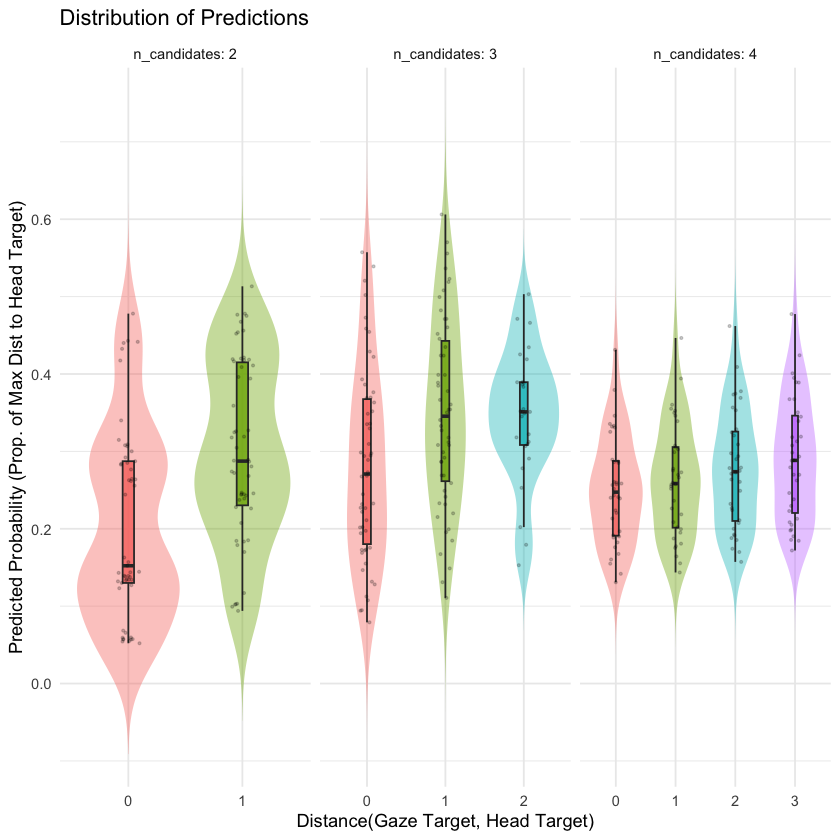

In [27]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Candidates)
preds <- predictions(m_head_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.



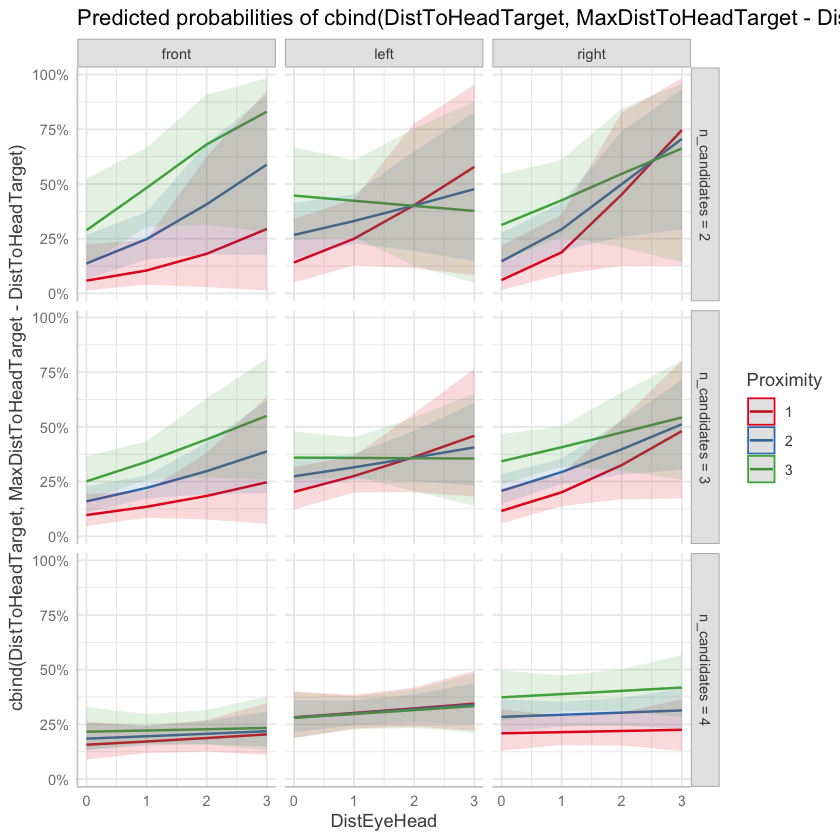

In [28]:
plot(ggpredict(
  m_head_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]")
))

### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. If the marginal means of IsHeadTarget for DistEyeHead=1, 2, and 3 are not significantly different from each other, but are all significantly lower than level 0, then Possibility 5 is supported. If the marginal mean gradually decreases, then Possibility 4 is supported.

In [29]:
m_hfreq_c <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_hfreq <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_hfreq_c, m_hfreq)

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_hfreq,9,1334.266,1378.684,-658.1330,1316.266,NA,NA,NA
m_hfreq_c,43,1372.049,1584.270,-643.0246,1286.049,30.21679,34,0.6536776


In [30]:
avg_predictions(m_hfreq_c, variables = "DistEyeHead", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),-0.00836950,0.03585589,-0.2334205,0.8154348722,0.2943584,-0.07864575,0.061906747
(2) - (0),-0.18076678,0.05007268,-3.6100882,0.0003060929,11.6737429,-0.27890742,-0.082626136
(3) - (0),-0.13656643,0.06597381,-2.0700096,0.0384514420,4.7008185,-0.26587273,-0.007260131
(2) - (1),-0.17239728,0.04815083,-3.5803591,0.0003431223,11.5089896,-0.26677118,-0.078023377
(3) - (1),-0.12819693,0.06255142,-2.0494646,0.0404167021,4.6289046,-0.25079547,-0.005598393
(3) - (2),0.04420035,0.07213786,0.6127205,0.5400611750,0.8888053,-0.09718726,0.185587955


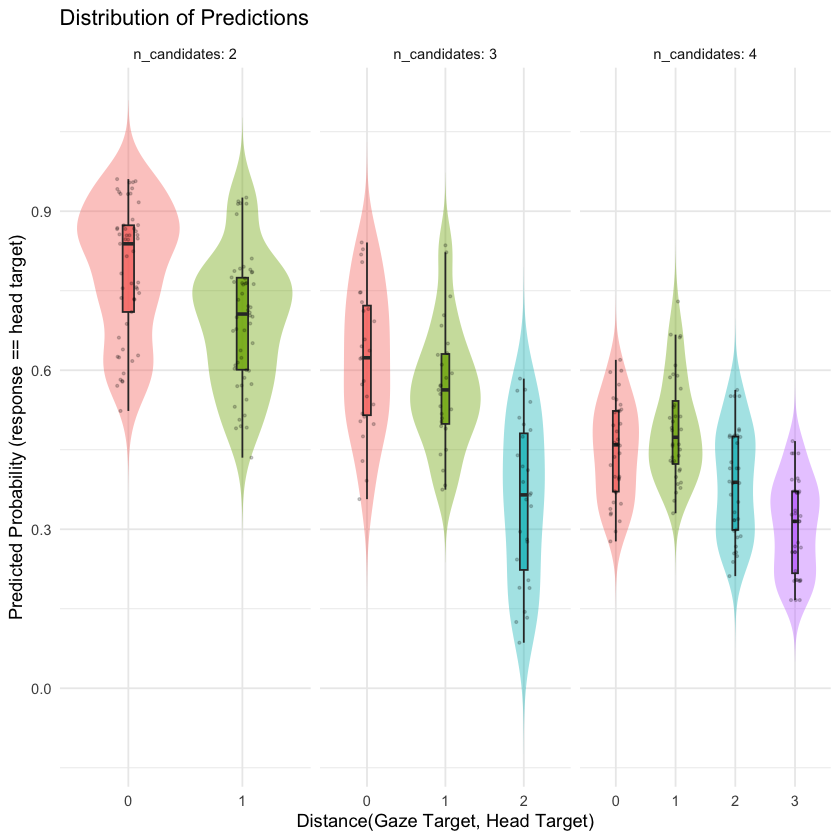

In [31]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_accuracy, Candidates)
preds <- predictions(m_hfreq_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (response == head target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

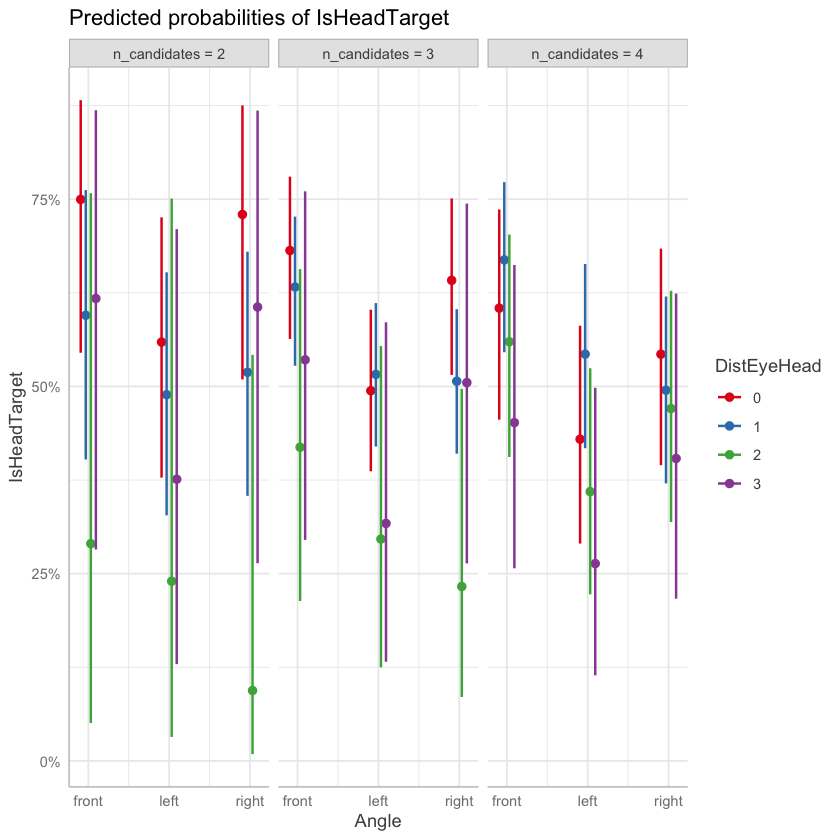

In [32]:
plot(ggpredict(
  m_hfreq_c, 
  terms = c("Angle [all]", "DistEyeHead [all]", "n_candidates [all]") # "Proximity [all]", 
))

### Look at View effects in different conditions (Exploratory)

In [33]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))
  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)
anova(model_view, model_view_c)

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_view,10,2349.307,2401.459,-1164.653,2329.307,NA,NA,NA
model_view_c,55,2331.854,2618.693,-1110.927,2221.854,107.4522,45,5.044209e-07


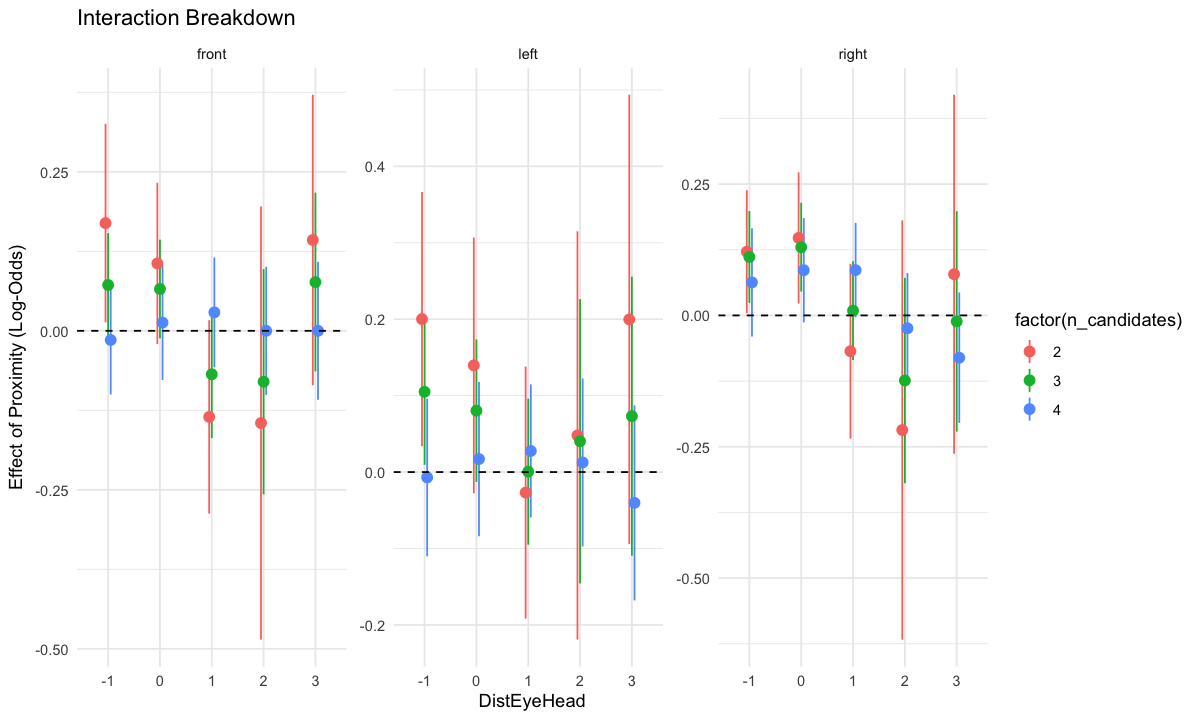

In [34]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

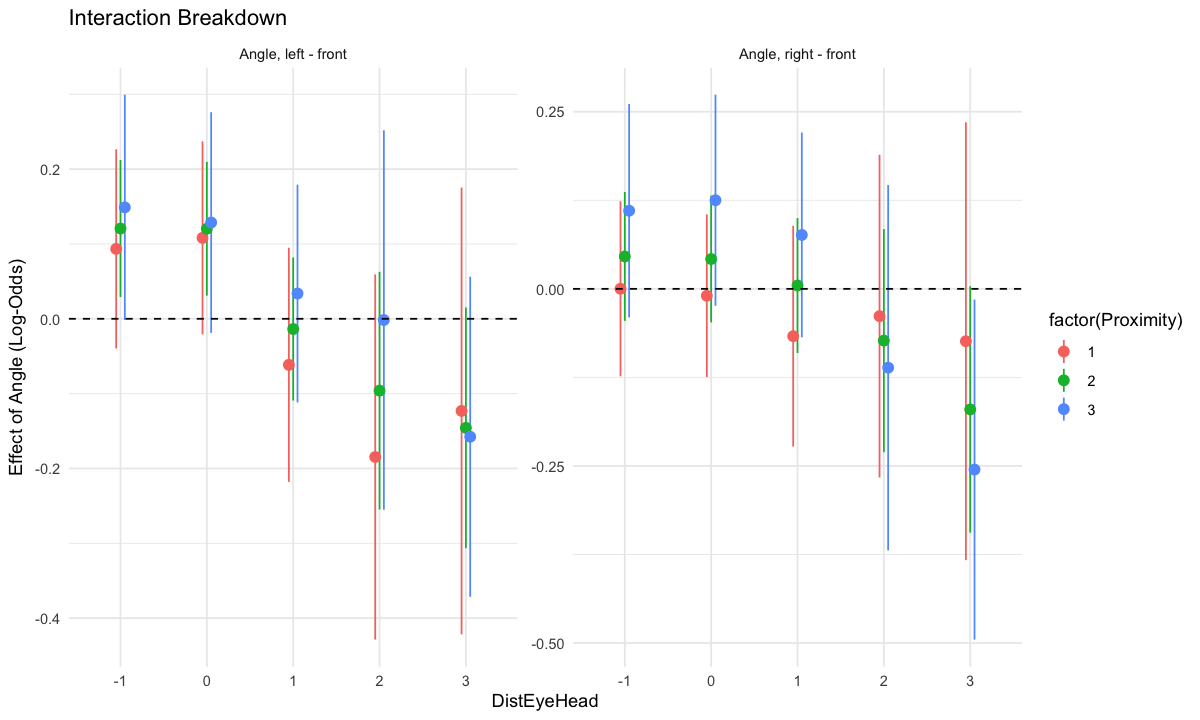

In [35]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

## On Stimuli A (Pilot)

This part is exploratory and not a concern of the pre-registration.

In [36]:
df_A <- df[df$Site == "Site0", ] # take Stimuli A results only
m_A_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + Actor + offset(offset_wrongness) + (1 | Actor:Candidates), data = df_A, family = binomial, control = strict_control)
m_A <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale=FALSE) + Actor + offset(offset_wrongness) + (1 | Actor:Candidates), data = df_A, family = binomial, control = strict_control)
isSingular(m_A_c)
isSingular(m_A)
anova(m_A, m_A_c)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] TRUE

[1] TRUE

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_A,7,1391.561,1425.178,-688.7805,1377.561,NA,NA,NA
m_A_c,14,1397.767,1465.001,-684.8837,1369.767,7.793685,7,0.3511378


In [37]:
avg_slopes(m_A, variables = "Proximity")
avg_slopes(m_A, variables = "n_candidates")
avg_comparisons(m_A, variables = "Angle")
avg_predictions(m_A, variables = "Actor", hypothesis = ~ pairwise, allow.new.levels = TRUE)

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.06839465,0.01615235,4.234346,2.292182e-05,15.41292,0.03673662,0.1000527,0.359094,0.3591079,0.359101


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,-0.04372588,0.01594835,-2.741718,0.006111872,7.35417,-0.07498407,-0.01246769,0.3591054,0.3590965,0.359101


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.09464555,0.03261323,2.90206,0.003707174,8.075465,0.0307248,0.1585663
Angle,right - front,0.07931848,0.03256911,2.43539,0.014875756,6.070893,0.0154842,0.1431528


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Y) - (X),0.07703766,0.02739164,2.812451,0.004916546,7.668139,0.02335103,0.1307243


## On Stimuli A & B (Exploratory) 

In [38]:
m1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates), data = df, family = binomial, control = strict_control)
m2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite), data = df, family = binomial, control = strict_control)
m3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | Candidates), data = df, family = binomial, control = strict_control)
compare_performance(m1, m2, m3, rank = TRUE)

Some of the nested models seem to be identical and probably only vary in
  their random effects.

Following indices with missing values are not used for ranking: Sigma,
  Log_loss



Name,Model,R2_conditional,R2_marginal,ICC,RMSE,Sigma,Log_loss,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
m3,glmerMod,0.03817057,0.02596010,0.012535905,0.4014254,1,NA,0.6155394,0.6176287,0.82797225,0.8408243
m1,glmerMod,0.03857126,0.02611442,0.012790864,0.4016521,1,NA,0.2721303,0.2696597,0.02093037,0.5553152
m2,glmerMod,0.03298637,0.02637572,0.006789735,0.4034402,1,NA,0.1123303,0.1127116,0.15109737,0.1658984


In [39]:
m1_simple <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale=FALSE) + offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates), data = df, family = binomial, control = strict_control)
anova(m1, m1_simple)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m1_simple,7,4040.862,4080.924,-2013.431,4026.862,NA,NA,NA
m1,14,4042.351,4122.475,-2007.176,4014.351,12.51044,7,0.08497371


In [40]:
model <- m1_simple
summary(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    offset(offset_wrongness) + (1 | ActorSite) + (1 | ActorSite:Candidates)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  4040.9   4080.9  -2013.4   4026.9     2253 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.6324 -0.8610 -0.1732  0.9576  2.5141 

Random effects:
 Groups               Name        Variance Std.Dev.
 ActorSite:Candidates (Intercept) 0.019450 0.13946 
 ActorSite            (Intercept) 0.005107 0.07146 
Number of obs: 2260, groups:  ActorSite:Candidates, 31; ActorSite, 4

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -0.63256    0.07570  -8.356  < 2e-16 ***
scale(Proximity, s

In [41]:
avg_slopes(model, variables = "Proximity")
avg_slopes(model, variables = "n_candidates")
avg_comparisons(model, variables = "Angle")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.03864526,0.009434187,4.096299,4.198068e-05,14.53991,0.02015459,0.05713592,0.3551108,0.3551184,0.3551146


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,-0.004069821,0.01350352,-0.3013895,0.7631175,0.3900229,-0.03053624,0.0223966,0.355115,0.3551142,0.3551146


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.03984409,0.01889413,2.108808,0.03496113,4.838104,0.0028122836,0.07687590
Angle,right - front,0.03723758,0.01889069,1.971214,0.04869945,4.359951,0.0002125134,0.07426265


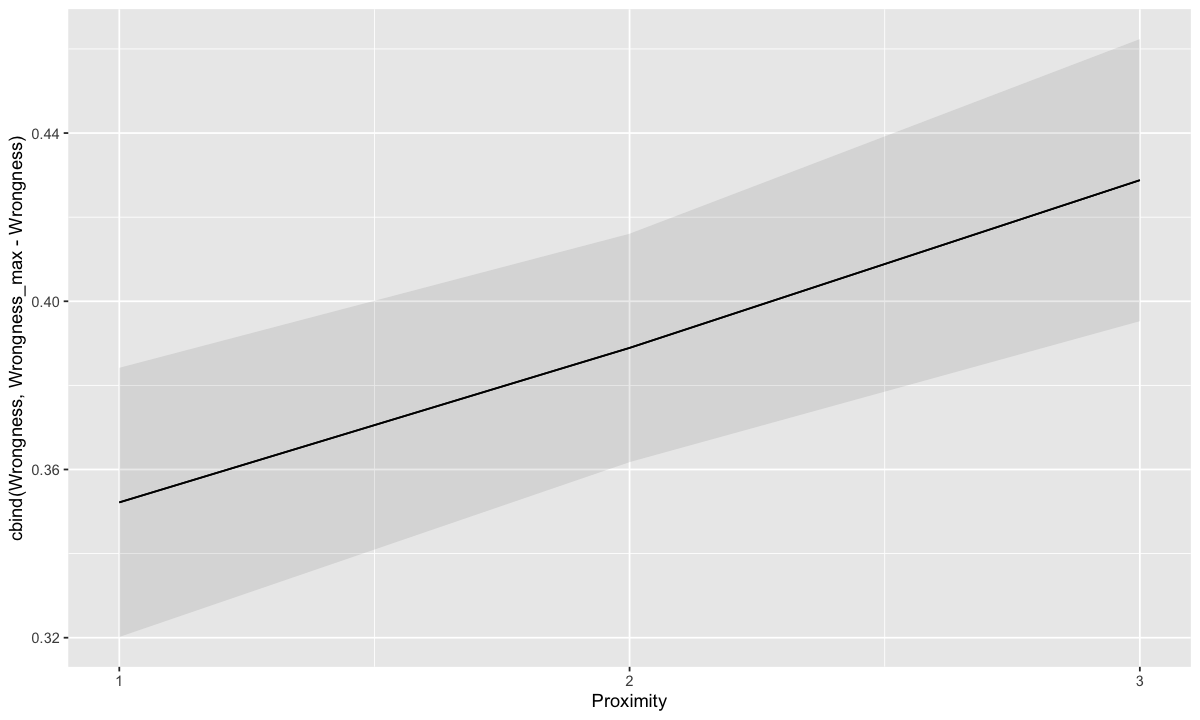

In [42]:
plot_predictions(model, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))

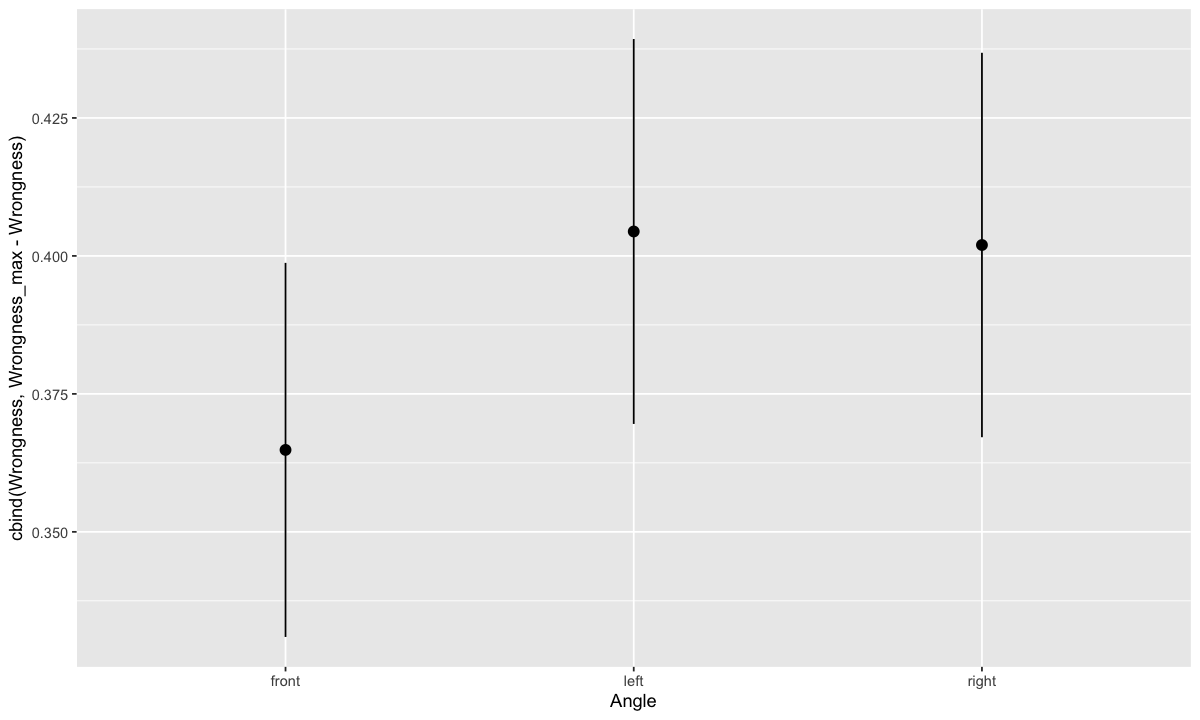

In [43]:
plot_predictions(model, by = c("Angle"))

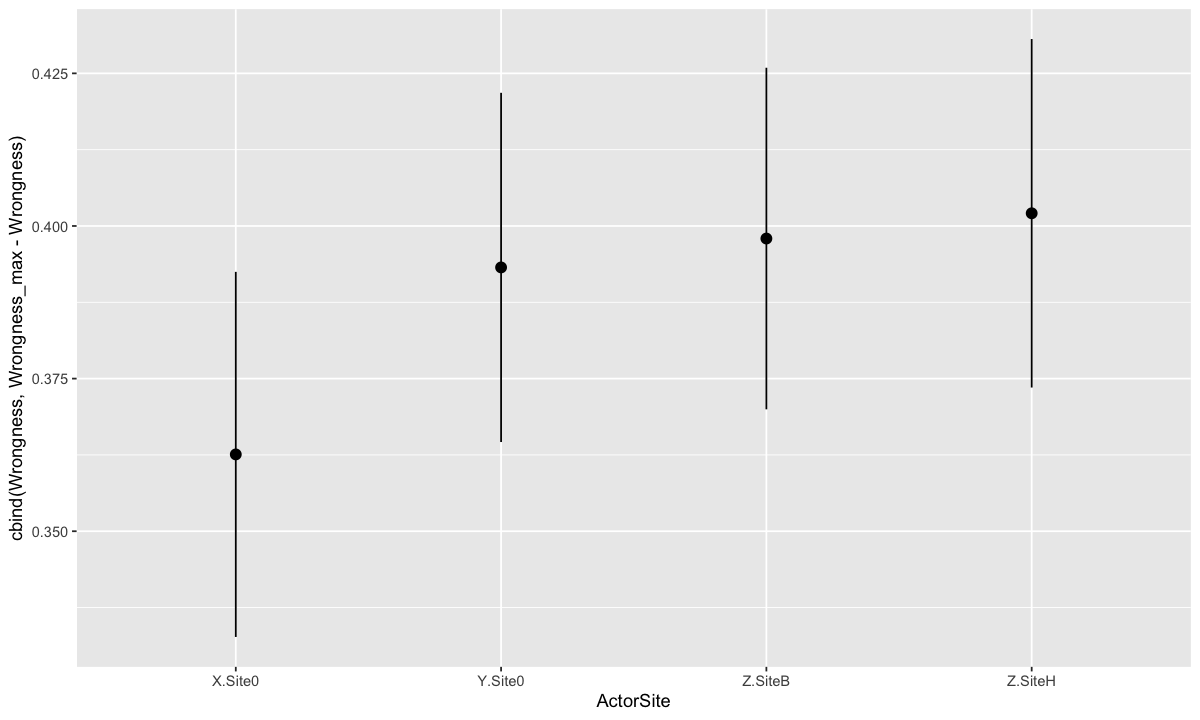

In [44]:
plot_predictions(model, by = c("ActorSite"))

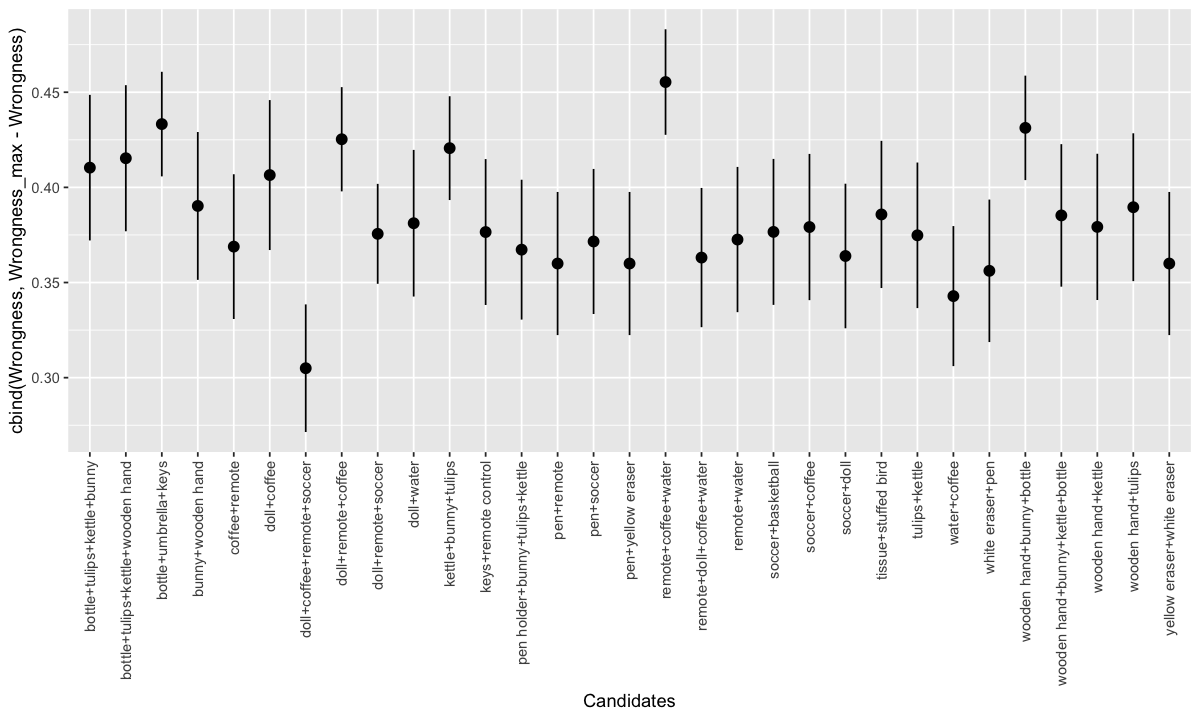

In [45]:
plot_predictions(model, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

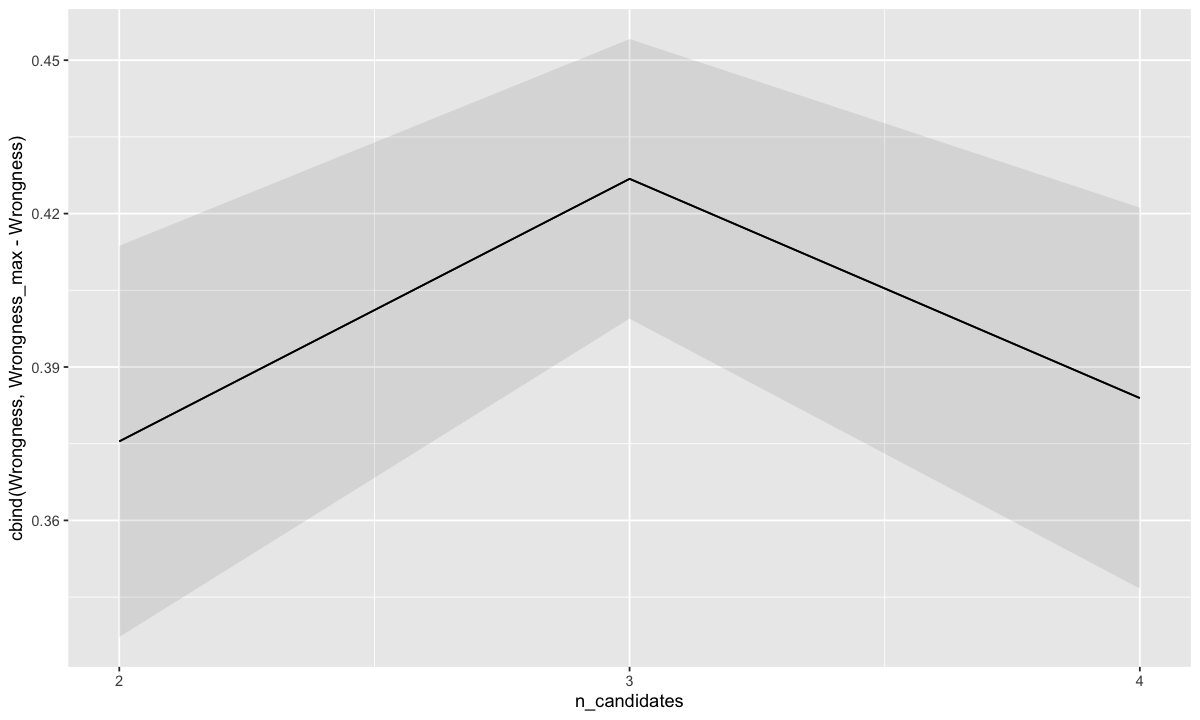

In [46]:
plot_predictions(model, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))